In [ ]:
# CELL 1 - Install Dependencies
# !pip install yfinance ta torch scikit-learn matplotlib seaborn pandas numpy -q


Dependencies installed


In [ ]:

import yfinance as yf
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec, seaborn as sns
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import AverageTrueRange, BollingerBands
import warnings, os
warnings.filterwarnings('ignore')

SEED = 7
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LOOKBACK = 30
BATCH    = 64
EPOCHS   = 80
LR       = 8e-4
WARMUP   = 8
PATIENCE = 25

STOCKS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
START, END = '2021-01-01', '2026-01-01'
print(f"Using device: {DEVICE}  |  Stocks: {STOCKS}")

Using device: cpu  |  Stocks: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']


In [3]:
# CELL 3 - Download OHLCV Data
def download_data(tickers, start, end):
    data = {}
    for t in tickers:
        df = yf.download(t, start=start, end=end, progress=False, auto_adjust=True)
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
        df.dropna(inplace=True)
        data[t] = df
        print(f"  {t}: {len(df)} trading days")
    return data

print("Downloading OHLCV data...")
raw_data = download_data(STOCKS, START, END)
print("Download complete")

  AAPL: 1255 trading days
  MSFT: 1255 trading days
  GOOGL: 1255 trading days
  AMZN: 1255 trading days
  TSLA: 1255 trading days
Download complete


In [4]:
# CELL 4 - Curated Feature Engineering (18 features: original 13 + 5 best additions)
FEATURE_COLS = [
    'returns', 'rolling_std_20', 'rolling_mean_20',
    'rsi', 'macd', 'macd_signal', 'macd_diff',
    'volume_change', 'volume_ratio', 'price_to_ma20',
    'high_low_range', 'open_close_diff',
    'ret_5d', 'ret_10d', 'std_5', 'std_10', 'atr_14', 'bb_pct'
]

def engineer_features(df):
    df = df.copy()
    c, h, l, o, v = df['Close'], df['High'], df['Low'], df['Open'], df['Volume']
    df['returns']  = c.pct_change()
    df['ret_5d']   = c.pct_change(5)
    df['ret_10d']  = c.pct_change(10)
    df['rolling_std_20']  = df['returns'].rolling(20).std()
    df['rolling_mean_20'] = df['returns'].rolling(20).mean()
    df['std_5']  = df['returns'].rolling(5).std()
    df['std_10'] = df['returns'].rolling(10).std()
    df['atr_14'] = AverageTrueRange(high=h, low=l, close=c, window=14).average_true_range() / c
    bb = BollingerBands(close=c, window=20, window_dev=2)
    df['bb_pct'] = bb.bollinger_pband()
    df['rsi'] = RSIIndicator(close=c, window=14).rsi()
    _macd = MACD(close=c)
    df['macd']       = _macd.macd()
    df['macd_signal']= _macd.macd_signal()
    df['macd_diff']  = _macd.macd_diff()
    df['volume_change'] = v.pct_change()
    vol_ma = v.rolling(20).mean()
    df['volume_ratio'] = v / vol_ma
    df['close_ma20'] = c.rolling(20).mean()
    df['price_to_ma20'] = c / df['close_ma20']
    df['high_low_range'] = (h - l) / c
    df['open_close_diff'] = (c - o) / o
    df['target'] = (c.shift(-1) > c).astype(int)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df

processed = {t: engineer_features(df) for t, df in raw_data.items()}
for t, df in processed.items():
    print(f"  {t}: {len(df)} rows | Up: {df['target'].mean()*100:.1f}%")
print(f"Feature engineering done - {len(FEATURE_COLS)} features")

  AAPL: 1222 rows | Up: 53.1%
  MSFT: 1222 rows | Up: 52.1%
  GOOGL: 1222 rows | Up: 53.8%
  AMZN: 1222 rows | Up: 51.5%
  TSLA: 1222 rows | Up: 51.5%
Feature engineering done - 18 features


In [5]:
# CELL 5 - Data Quality Report
for ticker, df in processed.items():
    nc = df[FEATURE_COLS].isna().sum().sum()
    ic = np.isinf(df[FEATURE_COLS].select_dtypes(include=[np.number])).sum().sum()
    print(f"  {ticker}: NaN={nc}, Inf={ic}, Rows={len(df)}")
print("Data quality: OK" if all(df[FEATURE_COLS].isna().sum().sum()==0 for df in processed.values()) else "Issues found")

  AAPL: NaN=0, Inf=0, Rows=1222
  MSFT: NaN=0, Inf=0, Rows=1222
  GOOGL: NaN=0, Inf=0, Rows=1222
  AMZN: NaN=0, Inf=0, Rows=1222
  TSLA: NaN=0, Inf=0, Rows=1222
Data quality: OK


In [6]:
# CELL 6 - Sequence Creation with StandardScaler
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):           return len(self.X)
    def __getitem__(self, idx):  return self.X[idx], self.y[idx]

def make_sequences(df, cols, lookback=30, val_r=0.1, test_r=0.2):
    """Chronological split with StandardScaler."""
    feat, target = df[cols].values, df['target'].values
    X, y = [], []
    for i in range(lookback, len(feat)):
        X.append(feat[i-lookback:i]); y.append(target[i])
    X, y = np.array(X), np.array(y)
    n = len(X)
    tr_end, vl_end = int(n*(1-val_r-test_r)), int(n*(1-test_r))
    X_tr, y_tr = X[:tr_end], y[:tr_end]
    X_vl, y_vl = X[tr_end:vl_end], y[tr_end:vl_end]
    X_te, y_te = X[vl_end:], y[vl_end:]
    scaler = RobustScaler()
    n_f = X_tr.shape[2]
    scaler.fit(X_tr.reshape(-1, n_f))
    X_tr = scaler.transform(X_tr.reshape(-1, n_f)).reshape(X_tr.shape)
    X_vl = scaler.transform(X_vl.reshape(-1, n_f)).reshape(X_vl.shape)
    X_te = scaler.transform(X_te.reshape(-1, n_f)).reshape(X_te.shape)
    return X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler

splits_per_stock = {}
arrs = {k: [] for k in ('Xtr','ytr','Xvl','yvl','Xte','yte')}
for ticker, df in processed.items():
    X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler = make_sequences(df, FEATURE_COLS, LOOKBACK)
    splits_per_stock[ticker] = dict(X_te=X_te, y_te=y_te, scaler=scaler,
                                    close=df['Close'].values, target=df['target'].values)
    arrs['Xtr'].append(X_tr); arrs['ytr'].append(y_tr)
    arrs['Xvl'].append(X_vl); arrs['yvl'].append(y_vl)
    arrs['Xte'].append(X_te); arrs['yte'].append(y_te)

X_train = np.concatenate(arrs['Xtr']); y_train = np.concatenate(arrs['ytr'])
X_val   = np.concatenate(arrs['Xvl']); y_val   = np.concatenate(arrs['yvl'])
X_test  = np.concatenate(arrs['Xte']); y_test  = np.concatenate(arrs['yte'])
print(f"Train: {X_train.shape} Up%: {y_train.mean():.2%}")
print(f"Val  : {X_val.shape}   Up%: {y_val.mean():.2%}")
print(f"Test : {X_test.shape}  Up%: {y_test.mean():.2%}")
train_loader = DataLoader(StockDataset(X_train, y_train), BATCH, shuffle=True, num_workers=0)
val_loader   = DataLoader(StockDataset(X_val, y_val), BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(StockDataset(X_test, y_test), BATCH, shuffle=False, num_workers=0)
print("DataLoaders ready (StandardScaler applied)")

Train: (4170, 30, 18) Up%: 51.99%
Val  : (595, 30, 18)   Up%: 54.96%
Test : (1195, 30, 18)  Up%: 52.80%
DataLoaders ready (StandardScaler applied)


In [7]:
# CELL 7 - StackedLSTM Model Definition
class StackedLSTM(nn.Module):
    """
    2-layer stacked LSTM for binary price-direction classification.
    Same architecture as dl.ipynb but with enhanced 18-feature input.
    Architecture: LSTM -> BatchNorm -> Dropout -> FC(128->64->1)
    """
    def __init__(self, input_size, hidden=128, layers=2, dropout=0.35):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden,
            num_layers=layers, dropout=dropout,
            batch_first=True, bidirectional=False
        )
        self.bn      = nn.BatchNorm1d(hidden)
        self.drop    = nn.Dropout(dropout)
        self.head    = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h      = out[:, -1, :]
        h      = self.bn(h)
        h      = self.drop(h)
        return self.head(h).squeeze(-1)

model = StackedLSTM(input_size=len(FEATURE_COLS)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model ready - {n_params:,} parameters")
print(model)

Model ready - 216,449 parameters
StackedLSTM(
  (lstm): LSTM(18, 128, num_layers=2, batch_first=True, dropout=0.35)
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop): Dropout(p=0.35, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [8]:
# CELL 8 - Loss, Optimizer, Scheduler
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
print(f"pos_weight = {pos_weight.item():.4f}")

def lr_lambda(epoch):
    if epoch < WARMUP: return (epoch + 1) / WARMUP
    progress = (epoch - WARMUP) / max(1, EPOCHS - WARMUP)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print("BCEWithLogitsLoss + AdamW + Cosine LR configured")

pos_weight = 0.9234
BCEWithLogitsLoss + AdamW + Cosine LR configured


In [9]:
# CELL 9 - Training Loop
def run_epoch(model, loader, optimizer=None, criterion=None, train=True):
    model.train() if train else model.eval()
    total_loss, probs, labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            labels.extend(y.cpu().numpy())
    probs, labels = np.array(probs), np.array(labels)
    acc = accuracy_score(labels, probs > 0.5)
    try: auc = roc_auc_score(labels, probs)
    except: auc = 0.5
    return total_loss / len(loader), acc, auc

history = {k: [] for k in ('tr_loss','vl_loss','tr_acc','vl_acc','vl_auc','lr')}
best_auc, best_state, stall = 0, None, 0
print(f"{'Ep':>3} {'LR':>8} {'TrLoss':>8} {'TrAcc':>7} {'VlLoss':>8} {'VlAcc':>7} {'VlAUC':>7}")
print("-" * 60)

for ep in range(EPOCHS):
    tr_loss, tr_acc, _ = run_epoch(model, train_loader, optimizer, criterion, train=True)
    vl_loss, vl_acc, vl_auc = run_epoch(model, val_loader, optimizer, criterion, train=False)
    scheduler.step()
    cur_lr = scheduler.get_last_lr()[0]
    history['tr_loss'].append(tr_loss); history['vl_loss'].append(vl_loss)
    history['tr_acc'].append(tr_acc);   history['vl_acc'].append(vl_acc)
    history['vl_auc'].append(vl_auc);   history['lr'].append(cur_lr)
    if vl_auc > best_auc:
        best_auc = vl_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        stall = 0; tag = " *"
    else: stall += 1; tag = ""
    if (ep + 1) % 5 == 0 or tag:
        print(f"{ep+1:3d} {cur_lr:8.5f} {tr_loss:8.4f} {tr_acc:7.4f} "
              f"{vl_loss:8.4f} {vl_acc:7.4f} {vl_auc:7.4f}{tag}")
    if stall >= PATIENCE:
        print(f"\nEarly stopping at epoch {ep+1}")
        break

model.load_state_dict(best_state)
print(f"\nTraining complete - Best Val AUC: {best_auc:.4f}")

 Ep       LR   TrLoss   TrAcc   VlLoss   VlAcc   VlAUC
------------------------------------------------------------
  1  0.00020   0.6826  0.4902   0.6653  0.4773  0.5047 *
  2  0.00030   0.6717  0.5175   0.6660  0.5059  0.5159 *
  5  0.00060   0.6723  0.5273   0.6635  0.5294  0.5343 *
  9  0.00080   0.6682  0.5283   0.6626  0.5546  0.5490 *
 10  0.00080   0.6646  0.5261   0.6690  0.5143  0.5188
 15  0.00078   0.6600  0.5420   0.6684  0.5378  0.5279
 20  0.00075   0.6557  0.5592   0.6714  0.4958  0.5080
 25  0.00069   0.6497  0.5693   0.6948  0.4840  0.4866
 30  0.00063   0.6408  0.5892   0.6956  0.4891  0.4987

Early stopping at epoch 34

Training complete - Best Val AUC: 0.5490


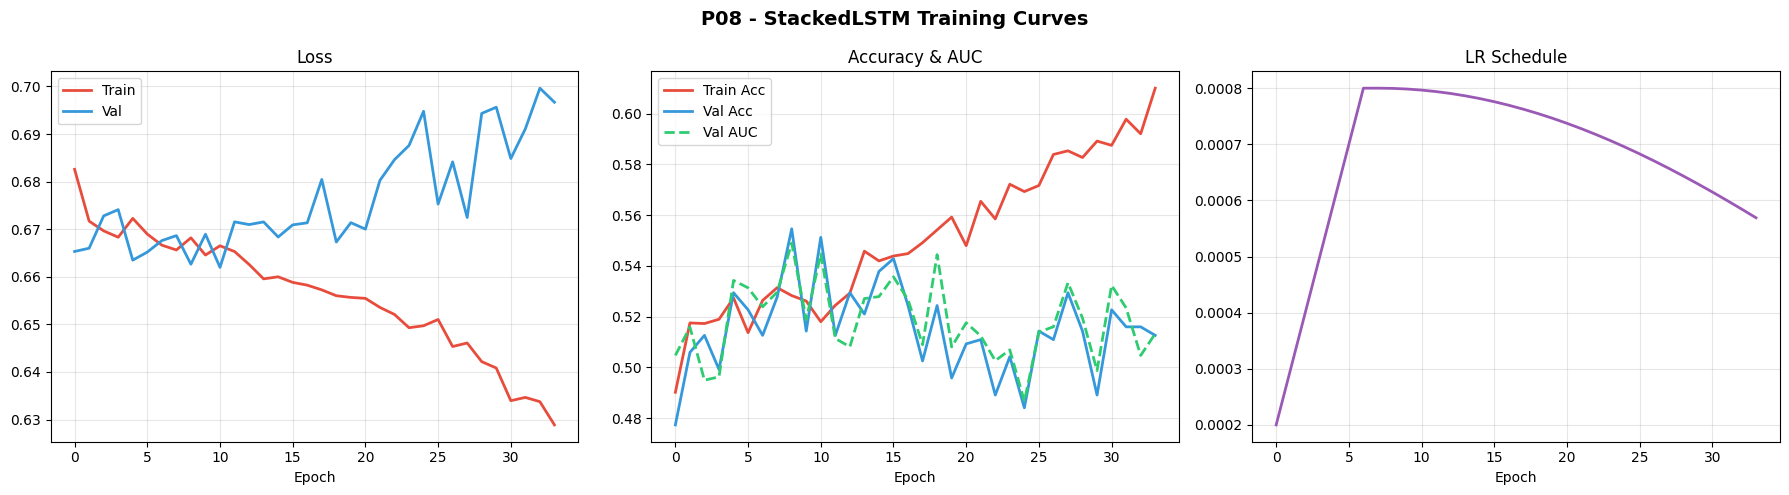

In [10]:
# CELL 10 - Training Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('P08 - StackedLSTM Training Curves', fontsize=14, fontweight='bold')
axes[0].plot(history['tr_loss'], label='Train', color='#E74C3C', lw=2)
axes[0].plot(history['vl_loss'], label='Val', color='#3498DB', lw=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['tr_acc'], label='Train Acc', color='#E74C3C', lw=2)
axes[1].plot(history['vl_acc'], label='Val Acc', color='#3498DB', lw=2)
axes[1].plot(history['vl_auc'], label='Val AUC', color='#2ECC71', lw=2, ls='--')
axes[1].set_title('Accuracy & AUC'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history['lr'], color='#9B59B6', lw=2)
axes[2].set_title('LR Schedule'); axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

In [11]:
# CELL 11 - Threshold Optimization on Validation Set
model.eval()
val_probs, val_labels = [], []
with torch.no_grad():
    for X, y in val_loader:
        val_probs.extend(torch.sigmoid(model(X.to(DEVICE))).cpu().numpy())
        val_labels.extend(y.numpy())
val_probs, val_labels = np.array(val_probs), np.array(val_labels)

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.30, 0.70, 0.01):
    f1 = f1_score(val_labels, (val_probs > t).astype(int), average='macro')
    if f1 > best_f1: best_f1 = f1; best_thresh = t

print(f"Optimal threshold: {best_thresh:.2f} (Val macro-F1: {best_f1:.4f})")
print(f"vs default 0.50:  (Val macro-F1: {f1_score(val_labels, (val_probs > 0.5).astype(int), average='macro'):.4f})")

Optimal threshold: 0.49 (Val macro-F1: 0.5635)
vs default 0.50:  (Val macro-F1: 0.5526)


  TEST RESULTS (out-of-sample)
  AUC-ROC          : 0.5069
  Accuracy (t=0.50): 0.5071
  Accuracy (t=0.49): 0.5121

  Classification Report (threshold=0.49):
              precision    recall  f1-score   support

        Down       0.48      0.39      0.43       564
          Up       0.53      0.62      0.57       631

    accuracy                           0.51      1195
   macro avg       0.51      0.51      0.50      1195
weighted avg       0.51      0.51      0.51      1195



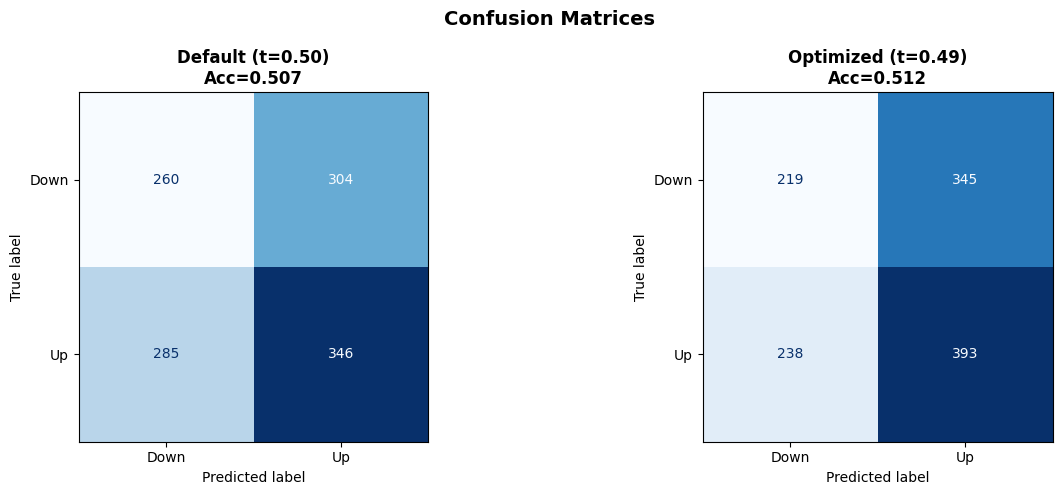

In [12]:
# CELL 12 - Test Set Evaluation
_, te_acc_default, te_auc = run_epoch(model, test_loader, criterion=criterion, train=False)
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        all_probs.extend(torch.sigmoid(model(X.to(DEVICE))).cpu().numpy())
        all_labels.extend(y.numpy())
all_probs, all_labels = np.array(all_probs), np.array(all_labels)
pred_cls_default = (all_probs > 0.5).astype(int)
pred_cls_opt = (all_probs > best_thresh).astype(int)
te_acc_opt = accuracy_score(all_labels, pred_cls_opt)

print("=" * 60)
print(f"  TEST RESULTS (out-of-sample)")
print("=" * 60)
print(f"  AUC-ROC          : {te_auc:.4f}")
print(f"  Accuracy (t=0.50): {te_acc_default:.4f}")
print(f"  Accuracy (t={best_thresh:.2f}): {te_acc_opt:.4f}")
print(f"\n  Classification Report (threshold={best_thresh:.2f}):")
print(classification_report(all_labels, pred_cls_opt, target_names=['Down','Up']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
for ax, preds, title in [
    (axes[0], pred_cls_default, f"Default (t=0.50)\nAcc={te_acc_default:.3f}"),
    (axes[1], pred_cls_opt, f"Optimized (t={best_thresh:.2f})\nAcc={te_acc_opt:.3f}")]:
    cm = confusion_matrix(all_labels, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Down','Up']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontweight='bold')
plt.tight_layout(); plt.savefig('lstm_confusion_matrix.png', dpi=150); plt.show()

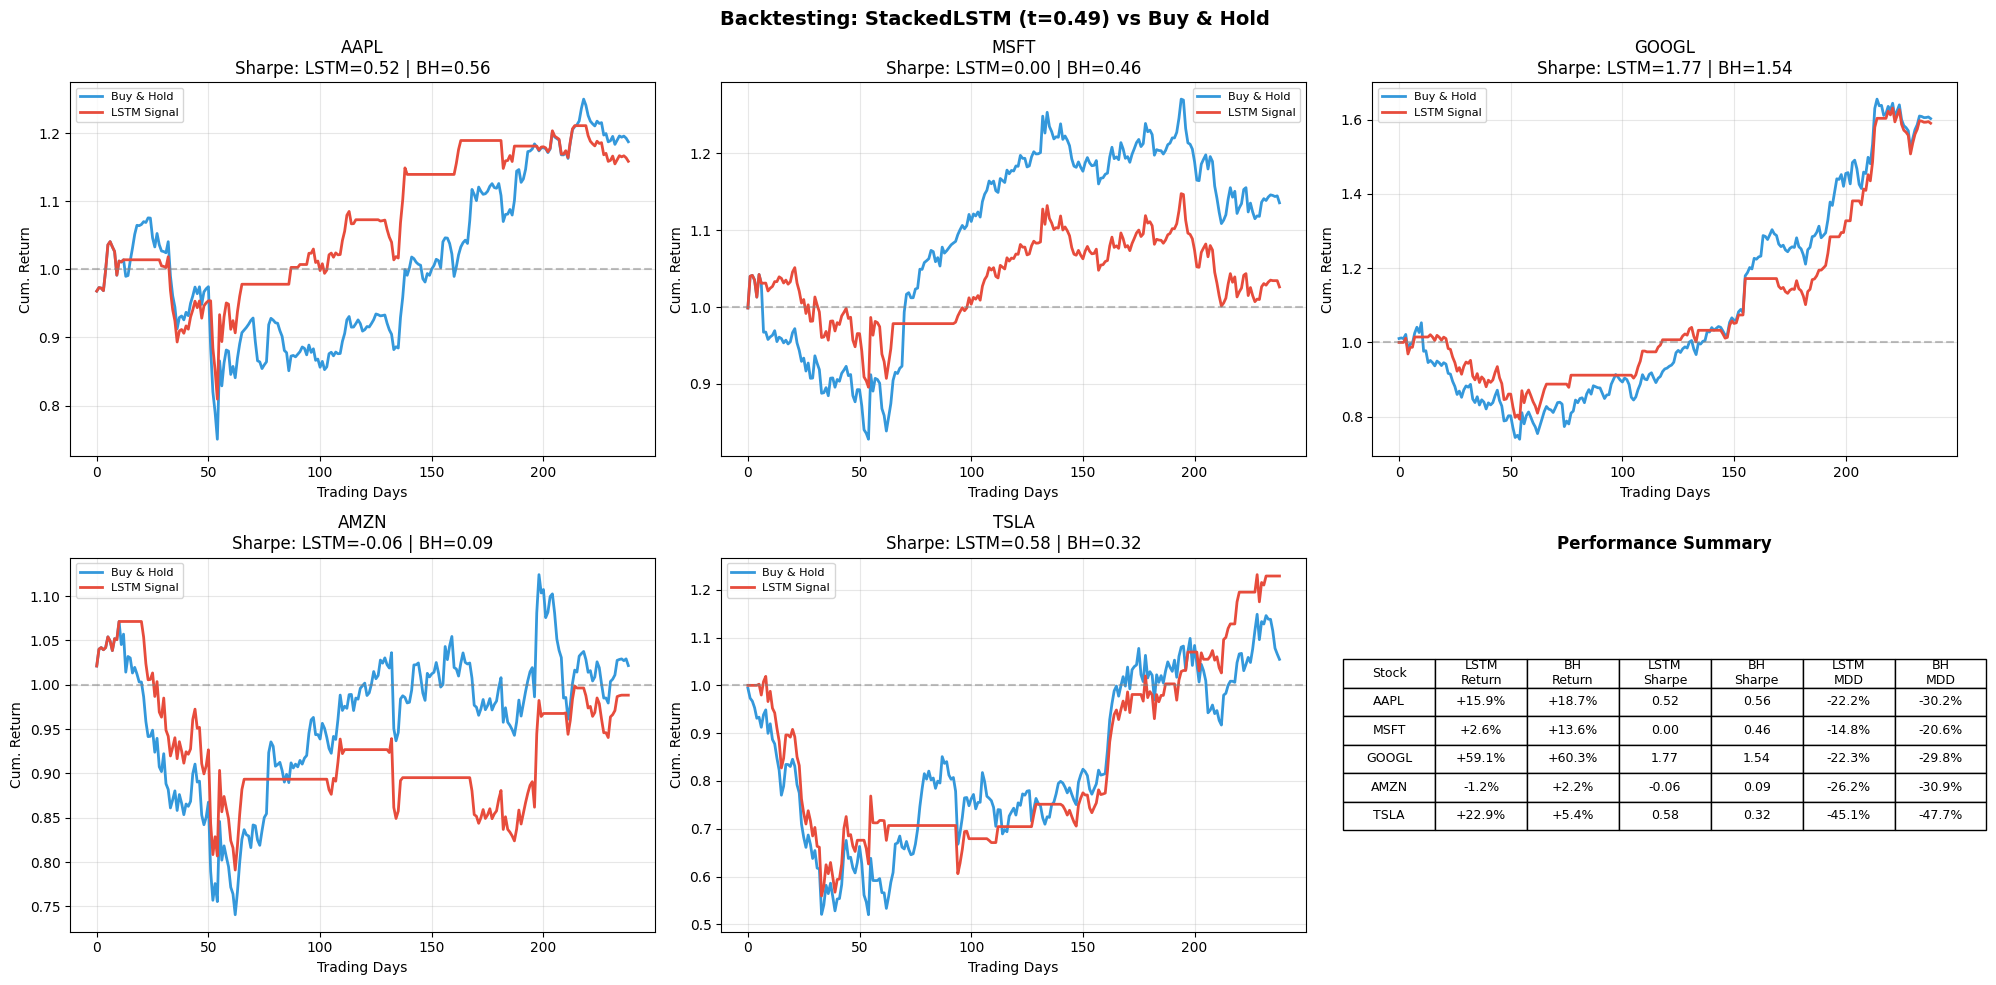


Stock      LSTM Ret     BH Ret  LSTM Sharpe  BH Sharpe
----------------------------------------------------------------------
AAPL         15.87%     18.74%        0.523      0.563
MSFT          2.61%     13.56%        0.001      0.465
GOOGL        59.07%     60.32%        1.766      1.536
AMZN         -1.18%      2.16%       -0.062      0.093
TSLA         22.87%      5.44%        0.579      0.323


In [13]:
# CELL 13 - Backtesting
def sharpe(returns, rf_annual=0.05):
    rf = rf_annual / 252; excess = returns - rf
    return (excess.mean() / (excess.std() + 1e-9)) * np.sqrt(252)

def max_drawdown(cum_returns):
    peak = np.maximum.accumulate(cum_returns)
    return ((cum_returns - peak) / peak).min()

def backtest_ticker(ticker, model, split_info, threshold=0.5):
    X_te, closes = split_info['X_te'], split_info['close']
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.FloatTensor(X_te).to(DEVICE))).cpu().numpy()
    signals = (probs > threshold).astype(float)
    n_test = len(X_te)
    test_close = closes[-(n_test + 1):]
    daily_ret = np.diff(test_close) / test_close[:-1]
    signals = signals[:len(daily_ret)]
    strat_ret, bh_ret = signals * daily_ret, daily_ret
    cum_strat, cum_bh = np.cumprod(1 + strat_ret), np.cumprod(1 + bh_ret)
    return {'ticker': ticker, 'cum_strat': cum_strat, 'cum_bh': cum_bh,
            'sharpe_strat': sharpe(strat_ret), 'sharpe_bh': sharpe(bh_ret),
            'mdd_strat': max_drawdown(cum_strat), 'mdd_bh': max_drawdown(cum_bh),
            'ret_strat': cum_strat[-1] - 1, 'ret_bh': cum_bh[-1] - 1,
            'win_rate': (strat_ret > 0).mean()}

bt_results = {t: backtest_ticker(t, model, splits_per_stock[t], threshold=best_thresh) for t in STOCKS}

fig = plt.figure(figsize=(20, 10))
fig.suptitle(f'Backtesting: StackedLSTM (t={best_thresh:.2f}) vs Buy & Hold',
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig)
for i, (ticker, r) in enumerate(bt_results.items()):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.plot(r['cum_bh'], label='Buy & Hold', color='#3498DB', lw=2)
    ax.plot(r['cum_strat'], label='LSTM Signal', color='#E74C3C', lw=2)
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.set_title(f"{ticker}\nSharpe: LSTM={r['sharpe_strat']:.2f} | BH={r['sharpe_bh']:.2f}")
    ax.set_xlabel('Trading Days'); ax.set_ylabel('Cum. Return')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax_tbl = fig.add_subplot(gs[1, 2]); ax_tbl.axis('off')
rows = [[r['ticker'], f"{r['ret_strat']:+.1%}", f"{r['ret_bh']:+.1%}",
         f"{r['sharpe_strat']:.2f}", f"{r['sharpe_bh']:.2f}",
         f"{r['mdd_strat']:.1%}", f"{r['mdd_bh']:.1%}"]
        for r in bt_results.values()]
tbl = ax_tbl.table(cellText=rows,
    colLabels=['Stock','LSTM\nReturn','BH\nReturn','LSTM\nSharpe','BH\nSharpe','LSTM\nMDD','BH\nMDD'],
    loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 1.6)
ax_tbl.set_title('Performance Summary', fontweight='bold')
plt.tight_layout(); plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight'); plt.show()

print("\n" + "="*70)
print(f"{'Stock':<8} {'LSTM Ret':>10} {'BH Ret':>10} {'LSTM Sharpe':>12} {'BH Sharpe':>10}")
print("-"*70)
for r in bt_results.values():
    print(f"{r['ticker']:<8} {r['ret_strat']:>10.2%} {r['ret_bh']:>10.2%} "
          f"{r['sharpe_strat']:>12.3f} {r['sharpe_bh']:>10.3f}")

In [14]:
# CELL 14 - Save Model Checkpoint
ckpt = {
    'model_state_dict': model.state_dict(),
    'config': {'input_size': len(FEATURE_COLS), 'hidden': 128, 'layers': 2, 'dropout': 0.35},
    'feature_cols': FEATURE_COLS,
    'lookback': LOOKBACK,
    'optimal_threshold': best_thresh,
    'scaler_type': 'StandardScaler',
    'metrics': {'test_acc': te_acc_opt, 'test_auc': te_auc, 'val_f1': best_f1},
    'hyperparams': {'lr': LR, 'batch': BATCH, 'warmup': WARMUP, 'seed': SEED}
}
torch.save(ckpt, 'lstm_p08_v3.pt')
print(f"Model saved: lstm_p08_v3.pt")
print(f"\n-- FINAL TEST METRICS --")
print(f"   Accuracy  : {te_acc_opt:.4f}  ({te_acc_opt*100:.1f}%)")
print(f"   AUC-ROC   : {te_auc:.4f}")
print(f"   Threshold : {best_thresh:.2f}")
print(f"   Scaler    : StandardScaler")

Model saved: lstm_p08_v3.pt

-- FINAL TEST METRICS --
   Accuracy  : 0.5121  (51.2%)
   AUC-ROC   : 0.5069
   Threshold : 0.49
   Scaler    : StandardScaler
